## Prédiction des prix immobiliers avec le Machine Learning

### 1. Exploration des données

In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv("Housing.csv")

In [3]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.shape

(545, 13)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
df["furnishingstatus"].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

### 2. Analyse exploratoire des données

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

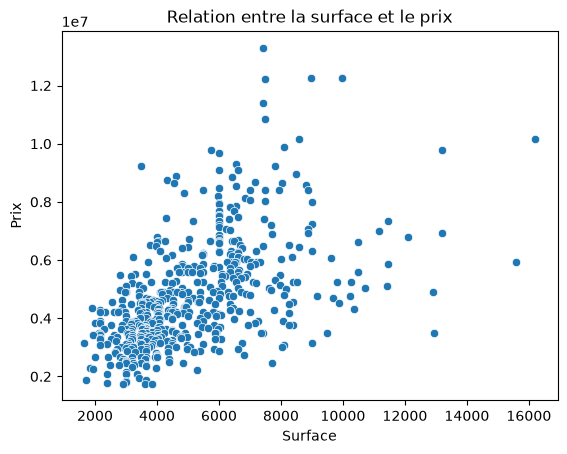

In [10]:
sns.scatterplot(data=df, x="area", y="price")
plt.xlabel("Surface")
plt.ylabel("Prix")
plt.title("Relation entre la surface et le prix")
plt.show()

In [11]:
colonnes_ = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
for colonne in colonnes_:
    print(f"\n{colonne}:")
    print(df[colonne].value_counts())


mainroad:
mainroad
yes    468
no      77
Name: count, dtype: int64

guestroom:
guestroom
no     448
yes     97
Name: count, dtype: int64

basement:
basement
no     354
yes    191
Name: count, dtype: int64

hotwaterheating:
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

airconditioning:
airconditioning
no     373
yes    172
Name: count, dtype: int64

prefarea:
prefarea
no     417
yes    128
Name: count, dtype: int64


In [12]:
df["area"].corr(df["price"])

np.float64(0.5359973457780801)

In [13]:
df[["price", "area", "bedrooms", "bathrooms", "stories", "parking"]].corr()["price"].sort_values(ascending=False)

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

#### Relation entre la superficie et le prix
**Observation :** On observe une tendance positive entre la superficie et le prix des logements. Les logements de plus grande superficie ont généralement un prix plus élevé. Cependant, la superficie ne suffit pas à expliquer toutes les variations de prix, ce qui suggère que d'autres caractéristiques du logement jouent également un rôle.

In [14]:
df.groupby("airconditioning")["price"].mean()

airconditioning
no     4.191940e+06
yes    6.013221e+06
Name: price, dtype: float64

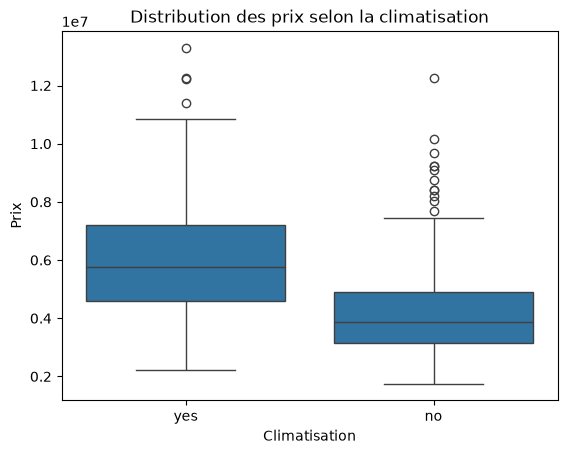

In [15]:
sns.boxplot(data=df, x="airconditioning", y="price")
plt.xlabel("Climatisation")
plt.ylabel("Prix")
plt.title("Distribution des prix selon la climatisation")
plt.show()

#### Distribution des prix selon la climatisation

Le boxplot montre que les logements équipés de la climatisation présentent globalement des prix plus élevés que ceux qui n'en disposent pas. La médiane des prix est notamment plus élevée pour les logements climatisés.

On observe également plusieurs valeurs atypiques dans les deux catégories, correspondant à des logements dont le prix est particulièrement élevé.

In [16]:
prix_moyen_meuble = df.groupby("furnishingstatus")["price"].mean().sort_values(ascending=False)

In [17]:
prix_moyen_meuble

furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64

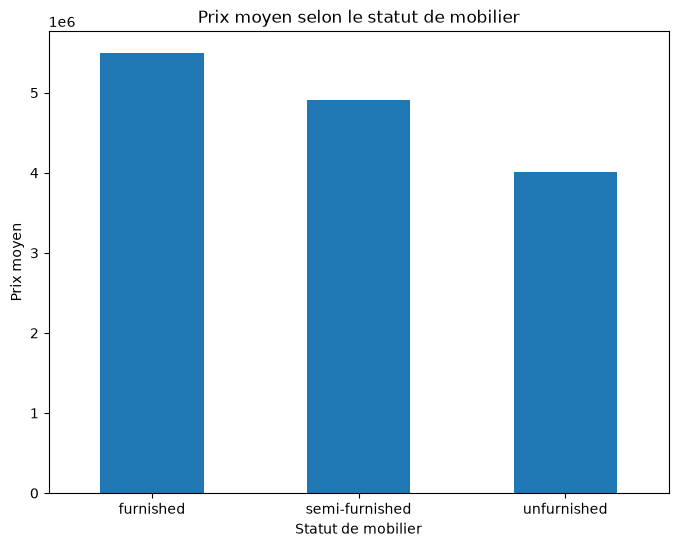

In [18]:
plt.figure(figsize=(8, 6))
prix_moyen_meuble.plot(kind="bar")
plt.xlabel("Statut de mobilier")
plt.ylabel("Prix moyen")
plt.title("Prix moyen selon le statut de mobilier")
plt.xticks(rotation=0)
plt.show()

#### Prix moyen selon le statut de mobilier

Les logements **meublés** présentent le prix moyen le plus élevé, suivis des logements **semi-meublés**. Les logements **non meublés** ont le prix moyen le plus faible.

Cette différence montre que le statut de mobilier peut être une caractéristique utile pour la prédiction du prix. Cependant, cette relation peut également être liée à d'autres caractéristiques des logements.

### 3. Préparation des données

In [19]:
df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

In [20]:
X = df.drop("price", axis=1)
y = df["price"]

In [21]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [22]:
y.head()

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [24]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (436, 12)
X_test  : (109, 12)
y_train : (436,)
y_test  : (109,)


In [25]:
X_train.dtypes

area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

#### Encoder les variables catégorielles

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_columns = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea", "furnishingstatus"]

preprocessor = ColumnTransformer(transformers=[("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_columns)],remainder="passthrough")

In [27]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [28]:
feature_names = preprocessor.get_feature_names_out()

In [29]:
X_train_encoded.shape

(436, 13)

### 4. Entraînement des modèles

In [30]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [31]:
model.fit(X_train_encoded, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 367919.95, 231610.04, 390251.18,...,1094444.79, 407476.59, 224841.91]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.6e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[45974.61, 20.83, 16.88,..., 6.45, 6. , 4.45]"


In [32]:
y_pred = model.predict(X_test_encoded)

In [33]:
y_pred[:5]

array([5164653.90033966, 7224722.29802162, 3109863.24240341,
       4612075.32722559, 3294646.25725959])

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [35]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [36]:
print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

MAE : 970043.403920169
RMSE : 1324506.9600914533
R² : 0.6529242642153108


### 5. Évaluation du modèle de régression linéaire

Le modèle obtient un **MAE d'environ 970 043** et un **RMSE d'environ 1 324 507**. Ces valeurs indiquent que les prédictions présentent des erreurs relativement importantes en termes de prix.

Le coefficient de détermination **R² = 0,653** indique que le modèle explique environ **65,3 % de la variabilité des prix** sur les données de test.

Ces résultats sont encourageants pour un premier modèle, mais ils montrent également qu'il existe une marge d'amélioration. Nous allons donc tester d'autres modèles de Machine Learning afin de comparer leurs performances.

In [37]:
from sklearn.ensemble import RandomForestRegressor

In [38]:
model_rf = RandomForestRegressor (n_estimators=100, random_state=42)

In [39]:
model_rf.fit(X_train_encoded, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [40]:
y_pred_rf = model_rf.predict(X_test_encoded)

In [41]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

In [42]:
print("MAE :", mae_rf)
print("RMSE :", rmse_rf)
print("R² :", r2_rf)


MAE : 1019926.1582568807
RMSE : 1398071.7886076658
R² : 0.6132995228410703


In [56]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train_encoded, y_train, cv=5, scoring="r2")

print("Scores R² :", scores)
print("R² moyen :", scores.mean())

Scores R² : [0.69856012 0.68386251 0.60963463 0.61909486 0.62404878]
R² moyen : 0.6470401792343304


#### Validation croisée

Une validation croisée à 5 plis a été réalisée afin de vérifier la stabilité des performances du modèle de régression linéaire.

Le modèle obtient un **R² moyen de 0,647**, avec des scores compris entre **0,610 et 0,699** selon les plis.

Ce résultat est proche du **R² de 0,653** obtenu précédemment sur les données de test, ce qui indique que les performances du modèle restent relativement stables selon les différentes partitions des données.

In [43]:
feature_importance = pd.Series(model_rf.feature_importances_, index=feature_names).sort_values(ascending=False)

feature_importance

remainder__area                         0.468553
remainder__bathrooms                    0.151518
cat__airconditioning_yes                0.062737
remainder__parking                      0.057367
remainder__stories                      0.057142
remainder__bedrooms                     0.048315
cat__furnishingstatus_unfurnished       0.034930
cat__basement_yes                       0.030949
cat__prefarea_yes                       0.030708
cat__hotwaterheating_yes                0.017234
cat__guestroom_yes                      0.016596
cat__furnishingstatus_semi-furnished    0.013661
cat__mainroad_yes                       0.010289
dtype: float64

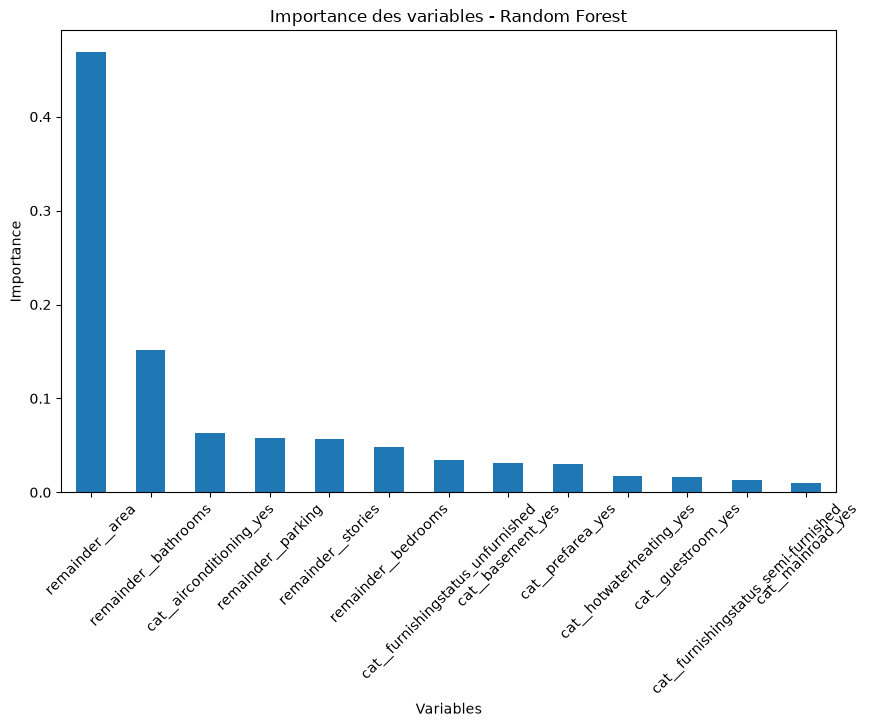

In [44]:
plt.figure(figsize=(10, 6))

feature_importance.plot(kind="bar")

plt.title("Importance des variables - Random Forest")
plt.xlabel("Variables")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

#### Importance des variables

L'analyse de l'importance des variables montre que certaines caractéristiques contribuent davantage aux prédictions du modèle Random Forest. Cette analyse permet d'identifier les variables les plus utilisées par le modèle pour estimer le prix des logements.

### Comparaison des modèles

La régression linéaire obtient de meilleures performances que la Random Forest sur les données de test. Elle présente un MAE et un RMSE plus faibles ainsi qu'un R² plus élevé. Elle est donc retenue comme modèle final pour la prédiction.

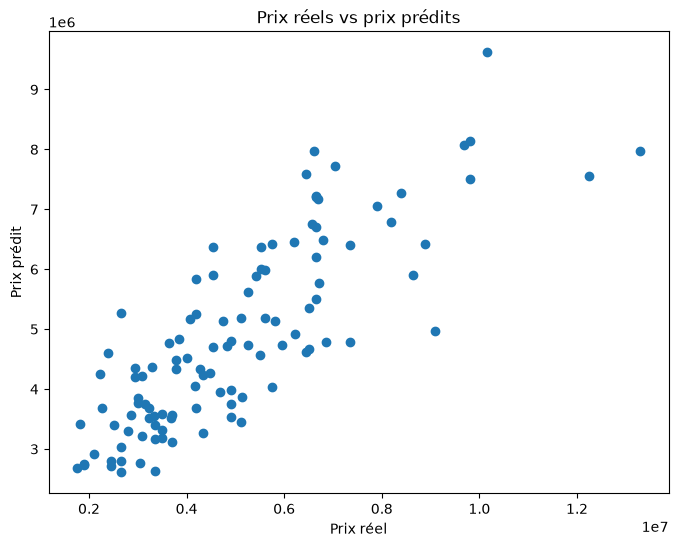

In [45]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Prix réels vs prix prédits")

plt.show()

#### Comparaison entre les prix réels et les prix prédits

Le graphique montre une tendance globalement croissante entre les prix réels et les prix prédits. Le modèle parvient donc à reproduire une partie des variations de prix.

Cependant, les points sont relativement dispersés, ce qui montre que certaines prédictions s'écartent encore significativement des valeurs réelles. Cette observation est cohérente avec le R² de 0,653 et le MAE d'environ 970 043.

### 6. Prédiction d'un nouveau logement

In [46]:
nouveau_logement = pd.DataFrame({
    "area": [5000],
    "bedrooms": [3],
    "bathrooms": [2],
    "stories": [2],
    "mainroad": ["yes"],
    "guestroom": ["yes"],
    "basement": ["yes"],
    "hotwaterheating": ["no"],
    "airconditioning": ["yes"],
    "parking": [1],
    "prefarea": ["yes"],
    "furnishingstatus": ["semi-furnished"]})

In [47]:
nouveau_logement_encoded = preprocessor.transform(nouveau_logement)

In [48]:
prix_predit = model.predict(nouveau_logement_encoded)
print("Prix estimé :", prix_predit[0])


Prix estimé : 7183113.805272914


Pour tester le modèle sur un logement qui n'appartient pas au jeu de données d'entraînement, nous avons défini un exemple de logement avec différentes caractéristiques.

Le modèle de régression linéaire estime son prix à environ **7 183 114** unités monétaires.

Cette valeur constitue une estimation et doit être interprétée en tenant compte des performances du modèle, notamment de son MAE d'environ **970 043**.

### 7. Interprétation et analyse des erreurs

In [49]:
coefficients = pd.Series(model.coef_, index=feature_names)

coefficients.sort_values(ascending=False)

remainder__bathrooms                    1.094445e+06
cat__airconditioning_yes                7.914267e+05
cat__hotwaterheating_yes                6.846499e+05
cat__prefarea_yes                       6.298906e+05
remainder__stories                      4.074766e+05
cat__basement_yes                       3.902512e+05
cat__mainroad_yes                       3.679199e+05
cat__guestroom_yes                      2.316100e+05
remainder__parking                      2.248419e+05
remainder__bedrooms                     7.677870e+04
remainder__area                         2.359688e+02
cat__furnishingstatus_semi-furnished   -1.268818e+05
cat__furnishingstatus_unfurnished      -4.136451e+05
dtype: float64

##### Interprétation des coefficients

Les coefficients du modèle montrent que certaines caractéristiques sont davantage associées aux variations du prix prédit. Le nombre de salles de bain présente le coefficient positif le plus élevé, suivi notamment par la présence de la climatisation, du chauffage à eau chaude et d'une localisation dans une zone préférée.
À l'inverse, les logements `semi-furnished` et `unfurnished` présentent des coefficients négatifs par rapport à la catégorie de référence `furnished`.
Ces résultats permettent de mieux comprendre les facteurs pris en compte par le modèle lors de la prédiction des prix.

In [50]:
erreurs = y_test - y_pred

erreurs_abs = abs(erreurs)

print("Erreur absolue moyenne :", erreurs_abs.mean())
print("Erreur absolue maximale :", erreurs_abs.max())

Erreur absolue moyenne : 970043.403920169
Erreur absolue maximale : 5331723.873612693


## 8. Conclusion
Ce projet avait pour objectif de prédire le prix des logements à partir de leurs caractéristiques en utilisant des techniques de Machine Learning. Après l'exploration et la préparation des données, deux modèles ont été entraînés et comparés : la régression linéaire et la Random Forest.

La régression linéaire a obtenu les meilleures performances sur les données de test, avec un **R² de 0,653**, un **MAE d'environ 970 043** et un **RMSE d'environ 1 324 507**. La validation croisée a également donné un **R² moyen de 0,647**, confirmant des performances relativement stables du modèle. La régression linéaire a ensuite été utilisée pour estimer le prix d'un nouveau logement.

L'analyse des erreurs et l'interprétation des variables ont permis de mieux comprendre les performances et les limites du modèle. Les résultats montrent qu'il peut fournir des estimations intéressantes, mais que certaines prédictions restent éloignées des valeurs réelles.

Ce projet m'a permis de mettre en pratique les principales étapes d'un projet de Data Science, de l'exploration et la préparation des données jusqu'à l'entraînement, l'évaluation, la comparaison et l'interprétation de modèles de Machine Learning.